# Hypothesis Testing

In [118]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## Inferential Statistics

*Inferential Statistics* goes beyond description and into:

1. making informed guess about a group of people / items
2. verify claims through data

<img src="https://datatab.net/assets/tutorial/Descriptive_statistics_and_inferential_statistics.png">

We do this through making claims, and test them systematically through well-defined procedures.

## What is a Hypothesis?

If a person claims that:

- coffee makes you awake at night
- sleep makes you taller
- exercise makes you smarter

Or even general statements like:

- people are addicted to smartphones
- people are more literate

How can we test those claims against reality?

### Definitions: Null vs. Alternative

In every test, we pit two statements against each other:

1. **Null Hypothesis ($H_0$):** The "status quo" or "no effect" statement. It assumes that any observed difference in your data is due to random sampling error (chance) rather than a true effect.
2. **Alternative Hypothesis ($H_a$ or $H_1$):** The statement you are trying to find evidence for. It claims there is a real effect, a difference, or a relationship.

### Anecdotal Evidence

**Anecdotal evidence** is information based on personal accounts, individual stories, or isolated incidents rather than on systematic data or scientific investigation.

Consider the following possible responses to the three research questions:

1. **A man on the news** got mercury poisoning from eating swordfish, so the average mercury concentration in swordfish must be dangerously high.
2. **I met two students** who took more than 7 years to graduate from Duke, so it must take longer to graduate at Duke than at many other colleges.
3. **My friend’s dad** had a heart attack and died after they gave him a new heart disease drug, so the drug must not work.

To put this to the test, we formulate both the null and the alternative hypothesis, and specify the parameter we would need to measure.

For the mercury case: We need to compare the mean mercury level across a large sample of swordfish against the FDA safety threshold (typically 1.0 ppm).

For the graduation case: We compare the distribution of graduation rates at Duke against the national average for 4-year private institutions.

For the medical drug case: In a clinical trial, some patients in the treatment group will inevitably die. We must test if the survival rate of those taking the drug is statistically higher than the survival rate of those in a control group (placebo).

The table following shows how this formulation compares:

| **Example**    | **H0​ (Null Hypothesis)**                   | **Ha​ (Alternative Hypothesis)**            | **Parameter of Interest**     |
| -------------- | ------------------------------------------- | ------------------------------------------- | ----------------------------- |
| **Mercury**    | Mean mercury $\le$ 1.0 ppm.                 | Mean mercury $>$ 1.0 ppm.                   | $\mu$ (Average Concentration) |
| **Duke Grad**  | Duke grad rate $\le$ National Avg.          | Duke grad rate $>$ National Avg.            | $p$ (Proportion of Graduates) |
| **Heart Drug** | Death rate (Drug) $=$ Death rate (Placebo). | Death rate (Drug) $<$ Death rate (Placebo). | $p$ (Survival Probability)    |

## Statistical Tests

Statisticians have developed many methods of testing such hypothesis, based on two factors:

Question we're trying to answer

1. significant difference in one variable? (t-test)
2. association between two categorical variables? (Chi-square)
3. association between two numerical variables? (Pearon's correlation coefficient)

### Interpreting the result of the test

The outcome of such tests is known to statisticians as the **p-value**:

- if it is below a threshold of `alpha = 0.05` (by convention from the scientific community) we **"reject"** the Null Hypothesis $H_0$
- if it is above that thershold, the test is inconclsuive; i.e., we **"fail to reject"**

Analogous to how, in a courtroom, the Null Hypothesis is: "people are innocent until proven guilty". A jury might:

- have enough evidence to declare the defendant "guilty"; i.e., he rejects the null hypothesis and accept the alternative claims due to enough evidence beyond reasonable doubt
- find the defendant "not guilty" **due to lack of evidence**, but, **they do not declare the defendant "innocent"**

Similarly, **if your test fails**, it just means you didn't have enough data to prove your alternative hypothesis. And this by no means proves that the null hypothesis is correct.


## Testing for Difference: T-tests

We'll start with the first: **difference**.

![](../../assets/t-test.png)

Learn more about the: [One sample t-test vs Independent t-test vs Paired t-test | YouTube video by: numiqo](https://youtu.be/Q_pO9NzWxPY?si=nJbx_ruQrBdtK3EC)

### Case 1: Compare a Sample Against the Population

In reality, this usually means we are making a **comparison against a historic or global value**. Examples:

- To compare the average **height** of a group of students ($\bar{x}$) to the average height of the general population ($\mu$).
- To compare the average **IQ** of a group of people ($\bar{x}$) to the average IQ of the general population ($\mu$).
- To compare the average **cholesterol levels** of a group of people ($\bar{x}$) to the recommended cholesterol levels ($\mu$).

### Case 2: Compare Independent Samples

They are two different groups of people:

- **Control group** takes a placebo drug (fake)
- **Treatment group** takes the real drug

### Case 3: Paired Samples

There are two cases for paired samples:

1. One group: usually looking for **comparison**
2. Two groups: usually seeking **relationship**

#### Case 3.1: One group

A group with the intervention and a group without the intervention:
 
 1. **Measure twice**, on the same group:
     - Grip strength — before vs. after eating spinach
     - Quiz scores — iPad notes vs. paper notes
     - Performance — with afternoon nap vs. without it
 2. **Two measurements**, on the same group:
     - Temperature under right armpit and under left armpit
     - BMI and Systolic Blood Pressure

#### Case 3.2 Two groups

Two groups where each record (sample) in the 1st group is naturally paired with a record (sample) in the 2nd group. For instance: 

   - twins (one in group A and one in group B)
   - husband-wife (one in group A and one in group B)
   - mother-baby (one in group A and one in group B)

### SciPy Stats Mapping

We'll be using `scipy.stats` package, and here is how it all fits togeher:

- **Comparision**
  - [1 Sample](https://docs.scipy.org/doc/scipy/reference/stats.html#one-sample-tests-paired-sample-tests): [`scipy.stats.ttest_1samp()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html)
  - 2 Samples
    - [Independent](https://docs.scipy.org/doc/scipy/reference/stats.html#independent-sample-tests): [`scipy.stats.ttest_ind()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
    - [Paired](https://docs.scipy.org/doc/scipy/reference/stats.html#one-sample-tests-paired-sample-tests): [`scipy.stats.ttest_rel()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html)
- [**Relationship**](https://docs.scipy.org/doc/scipy/reference/stats.html#association-correlation-tests):
  - Numerical: [`pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html#scipy.stats.pearsonr) or [`spearmanr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html#scipy.stats.spearmanr)
  - Categorical: [`chi2_contingency()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html) followed by [`association()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html)

![Decision Tree: Selecting a Statistical Test](../../assets/comparison_and_relationship.png)

**Assumptions:** All "T-tests" (comparisons) assume the underlying data follows a normal distribution. If your data is heavily skewed or contains outliers that violate this, the non-parametric alternatives (Mann-Whitney or Wilcoxon) are the mathematically "truthful" choices as they rely on ranks rather than raw values.

## Examples

### Hypothesis $H_1$: the average height of NBA player is higher than the average height of the general population

In [ ]:
# Source NBA Heights: https://github.com/simonwarchol/NBA-Height-Weight/blob/master/CSVs/total.csv
nba = pd.read_csv('../../data/nba_heights.csv')
nba.describe()

,h_meters,h_in
count,435.000000,435.000000
mean,2.012483,79.209195
std,0.090078,3.573444
min,1.750000,69.000000
25%,1.960000,77.000000
50%,2.030000,80.000000
75%,2.080000,82.000000
max,2.290000,90.000000


In [ ]:
# Source Human Heights: https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset
humans = pd.read_csv('../../data/SOCR-HeightWeight.csv')
humans.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


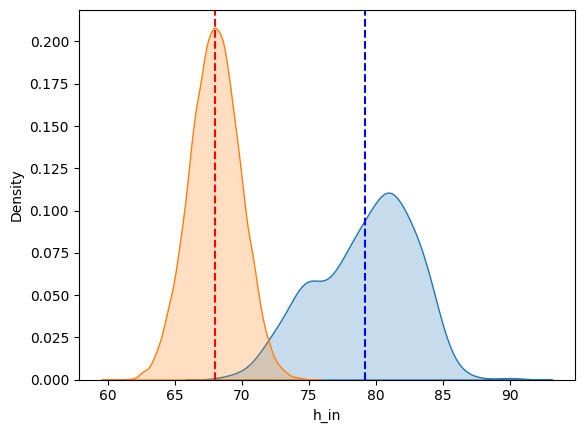

In [123]:
# plot smooth kde distribution of body mass for two sexes overlapping
sns.kdeplot(nba, x='h_in', fill=True)
sns.kdeplot(humans, x='Height(Inches)', fill=True)

# vertical line at the mean of the height for both
plt.axvline(humans['Height(Inches)'].mean(), color='red', linestyle='--')
plt.axvline(nba['h_in'].mean(), color='blue', linestyle='--')

#### Testing the hypothesis

to test the hypothesis we need to, firstly, select the **Significance Level** `alpha`. By convention (of the scientific community) it is set to `0.05`, and we don't have a reason to change it.

In [124]:
# significance level
alpha = 0.05

Secondly, when comparing we have three options

1. `alternative="two-sided"` the mean of the underlying distribution ($\bar{x}$) **of the sample is different** than the given population mean (popmean: $\mu$)
2. `alternative="less"` the mean of the underlying distribution ($\bar{x}$) **of the sample is less** than the given population mean (popmean: $\mu$)
3. `alternative="greater"` the mean of the underlying distribution ($\bar{x}$) **of the sample is greater** than the given population mean (popmean: $\mu$)

In [125]:
# comparison > 1 sample => ttest_1samp()
t_statistic, p_value = stats.ttest_1samp(
    a=nba['h_in'],
    popmean=humans['Height(Inches)'].mean(),
    alternative="greater",
)

The outcome of the test is a tuple:

1. `t_statistic`
2. `p_value`

We only care about the `p_value` being less than the threshold `alpha`:

In [135]:
print(f"p_value: {p_value:.2e}")

if p_value <= alpha:
    print("Conclusion: NBA players are taller than the general population")
else:
    print("Conclusion: not enough evidence to support the claim that NBA players are taller than the general population")

p_value: 2.53e-227
Conclusion: NBA players are taller than the general population


### Hypothesis $H_2$: male penguins weigh more than female penguins

In [ ]:
penguins = sns.load_dataset('penguins')
penguins.dropna(inplace=True)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Let's look at the distribution of `body_mass_g` shown for each `sex` separately:

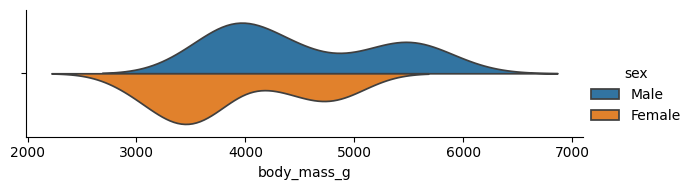

In [54]:
sns.catplot(
    penguins,
    x='body_mass_g',
    hue='sex',
    kind='violin',
    split=True,
    inner=None,
    height=2, aspect=3
)

In [ ]:
# significance level
alpha = 0.05

# comparison > 2 samples > independent => ttest_ind()
t_statistic, p_value = stats.ttest_ind(
    penguins.loc[penguins["sex"] == "Male", 'body_mass_g'],
    penguins.loc[penguins["sex"] == "Female", 'body_mass_g'],
    alternative="greater",
)

print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("significant!" if p_value <= alpha else "not enough evidence")

t-statistic: 8.541720337994516
p-value: 2.448623375798112e-16
significant!


### Hypothesis $H_3$: smokers give higher tips than non-smokers

In [47]:
import seaborn as sns

tips = sns.load_dataset('tips')
tips.dropna(inplace=True)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Let's look at the box plot:

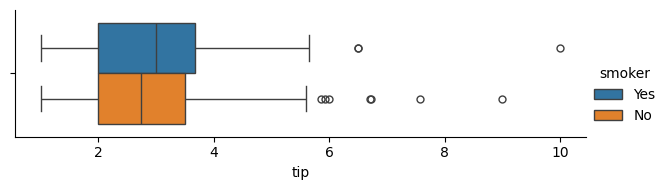

In [53]:
sns.catplot(
    tips,
    x='tip',
    hue='smoker',
    kind='box',
    height=2, aspect=3
)

In [ ]:
from scipy import stats

# significance level
alpha = 0.05

# comparison > 2 samples > independent => ttest_ind()
t_statistic, p_value = stats.ttest_ind(
    tips.loc[tips["smoker"] == "Yes", 'tip'],
    tips.loc[tips["smoker"] == "No", 'tip'],
    alternative="greater",
)

print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("significant!" if p_value <= alpha else "not enough evidence")

t-statistic: 0.09222805186888201
p-value: 0.4632965761122488
not enough evidence


### Hypothesis $H_4$: spinach increases grip strength

In [76]:
# Made up some experimental data
grip = pd.DataFrame({
    "subject": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    "before": [50, 52, 55, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 72],
    "after": [60, 68, 50, 55, 59, 61, 62, 63, 64, 65, 66, 67, 68, 70, 72, 73, 75, 76, 77, 78],
})

We could look at the distribution, `before` and `after`:

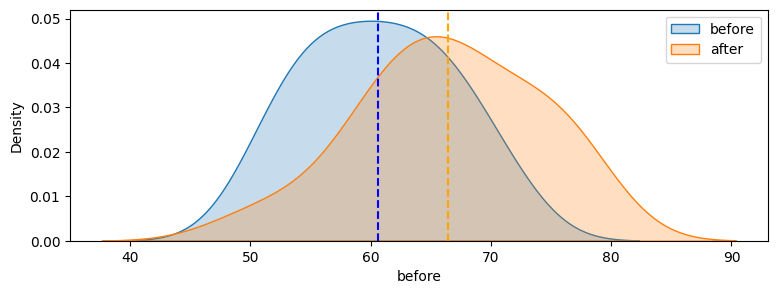

In [112]:
# plot smooth kde distribution of body mass for two sexes overlapping
fig, ax = plt.subplots(figsize=(9, 3))

sns.kdeplot(grip, x='before', fill=True, ax=ax)
sns.kdeplot(grip, x='after', fill=True, ax=ax)

# legend
ax.legend(['before', 'after'])

# vertical line at the mean of before and after
ax.axvline(grip['before'].mean(), color='blue', linestyle='--')
ax.axvline(grip['after'].mean(), color='orange', linestyle='--');


To draw a relational plot for each subject, we need to `melt` the dataframe to have a column indicated who took the treatment and who did not:

In [69]:
df_grip = grip.melt(id_vars=['subject'], value_vars=['before', 'after'])
df_grip.sample(5)

,subject,variable,value
31,12,after,67
29,10,after,65
36,17,after,75
10,11,before,61
2,3,before,55


Now we can look at each subject's performance, using the `relplot(kind="line")` like so:

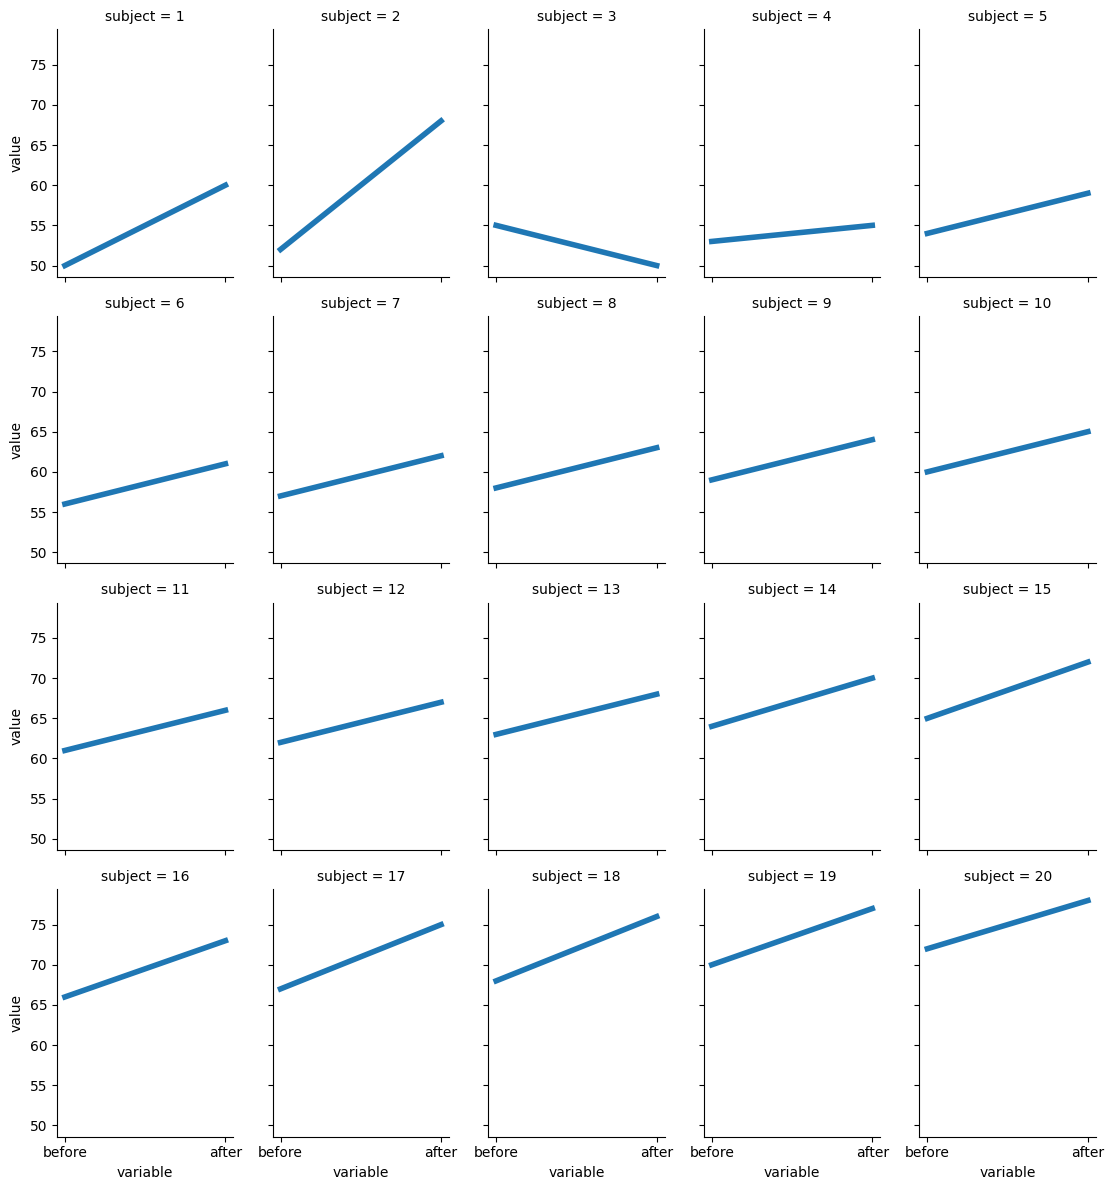

In [ ]:
sns.relplot(
    df_grip,
    kind='line',
    x='variable',
    y='value',
    col='subject', col_wrap=5,
    height=3, aspect=.75, linewidth=4,
)

Since we are looking for **change** we need to measure the `difference`:

In [ ]:
grip['difference'] = grip['after'] - grip['before']

Let's have a look at the statistics of the data now:

In [ ]:
grip.describe()

,subject,before,after,difference
count,20.00000,20.00000,20.000000,20.000000
mean,10.50000,60.60000,66.450000,5.850000
std,5.91608,6.26099,7.500702,3.787445
min,1.00000,50.00000,50.000000,-5.000000
25%,5.75000,55.75000,61.750000,5.000000
50%,10.50000,60.50000,66.500000,5.000000
75%,15.25000,65.25000,72.250000,7.000000
max,20.00000,72.00000,78.000000,16.000000


Using a `catplot(kind="point")` plot, one can visualize the **mean and standard deviation** of the `diffference` for the sample, not individuals:

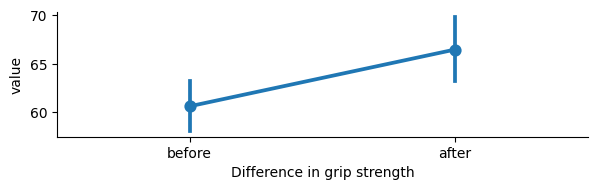

In [105]:
g = sns.catplot(
    df_grip,
    x='variable',
    y='value',
    kind='point',
    height=2, aspect=3
)
g.set_xlabels("Difference in grip strength");

In [ ]:
from scipy import stats

# Determine significance level
alpha = 0.05

# comparison > 2 samples > paired => ttest_rel()
t_statistic, p_value = stats.ttest_rel(
    grip['after'],
    grip['before'],
    alternative="greater",
)

print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("significant!" if p_value <= alpha else "not enough evidence")

t-statistic: 6.907558493188381
p-value: 6.898776102555165e-07
significant!


### One-way ANOVA and Tukey HSD

**An ANOVA (Analysis of Variance**) is a statistical method used to determine if there are statistically significant differences between the means of three or more independent groups.

While a t-test is used to compare the means of exactly two groups, the ANOVA is the "heavy lifter" used when your categorical variable has multiple levels. Example:

1. comparing three different dosages of a drug (10ml, 20ml, and 30ml)
2. or four different studying methods (Flash-cards, Rereding, Practice Tests, and Retrieval)

You might wonder: "Why not just run three separate t-tests to compare Group A vs. B, B vs. C, and A vs. C?"

The answer is **Type I Error (False Positives)**. Every time you run a statistical test, there is usually a 5% chance ($\alpha = 0.05$) of finding a "significant" result purely by luck. If you run many tests, those 5% chances add up.

- **1 test:** 5% risk of error.
- **3 tests:** ~14% risk of error.
- **ANOVA** allows you to test all groups at once while keeping that total risk at 5%.

If you get a significant result, you know that "at least one group is different," but you don't know if Group A is better than B, or if C is the only outlier. To find out exactly which groups differ, you must run a Post-Hoc Test (like the Tukey HSD).

As such, we will only show **Tukey’s HSD (Honestly Significant Difference)**. It tells you which specific pairs are different while controlling for the increased risk of false positives.

#### Hypothesis $H_5$: weights of penguins across species do differ

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins.dropna(inplace=True)

/tmp/ipykernel_5791/3082984041.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.swarmplot(


<Axes: xlabel='species', ylabel='body_mass_g'>

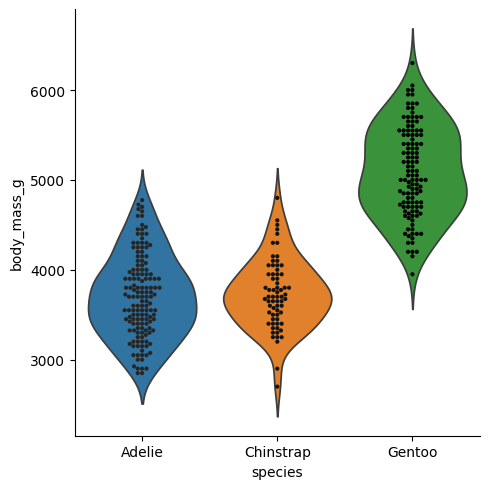

In [118]:
g = sns.catplot(
    data=penguins, 
    x="species",
    hue="species",
    y="body_mass_g", 
    kind="violin", 
    inner=None
)

sns.swarmplot(
    data=penguins, 
    x="species",
    hue="species", 
    y="body_mass_g", 
    color="k", 
    size=3,
    ax=g.ax
)


In [99]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

alpha = 0.05

# Use pairwise_tukeyhsd for post-hoc analysis across species
tukey = pairwise_tukeyhsd(endog=penguins['body_mass_g'],
                          groups=penguins['species'],
                          alpha=alpha)

print(tukey)
print("significant!" if (tukey.reject.any()) else "not enough evidence")

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower     upper   reject
---------------------------------------------------------------
   Adelie Chinstrap   26.9239 0.9164 -132.3528  186.2005  False
   Adelie    Gentoo 1386.2726    0.0 1252.2897 1520.2554   True
Chinstrap    Gentoo 1359.3487    0.0 1194.4304 1524.2671   True
---------------------------------------------------------------
significant!
